# Bank Marketing Dataset: Data Inspection, Visualisation and MLP Classification

This notebook downloads the Kaggle **Bank Marketing Dataset**, performs reproducible data-quality checks and preprocessing, summarises and visualises the data, and trains a multilayer perceptron (MLP) for binary classification.

The target is `deposit`: `yes` is encoded as 1 and `no` as 0. The default experiment uses every supplied feature, including `duration`, and therefore answers an **after-call outcome classification** question. If the intended use is pre-call customer targeting, set `USE_DURATION = False` below because call duration is not known before a call finishes.

Team members:
Gu Shucheng (G2605220E)
Lim Renyi (G2609306E)

## 1. Environment and reproducibility

Run the installation cell once if these packages are not already available. The model itself uses scikit-learn's `MLPClassifier`, so no GPU or TensorFlow installation is required.

In [1]:
%pip install -q kagglehub pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
from __future__ import annotations

import copy
import hashlib
import random
import warnings
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import gaussian_kde
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

SEED = 42
TEST_SIZE = 0.15
VALIDATION_SIZE = 0.15
USE_DURATION = True
MAX_EPOCHS = 100
PATIENCE = 12
MIN_DELTA = 1e-4

random.seed(SEED)
np.random.seed(SEED)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")
warnings.filterwarnings("ignore", category=FutureWarning)

print(f"Random seed: {SEED}")
print(f"Use call duration: {USE_DURATION}")

Random seed: 42
Use call duration: True


## 2. Download and load the Kaggle dataset

The loader uses `kagglehub` to retrieve the public dataset into its default cache location. It prints the selected file and SHA-256 checksum so that the exact input can be recorded in the report.

In [3]:
DATASET_HANDLE = "janiobachmann/bank-marketing-dataset"
download_dir = Path(kagglehub.dataset_download(DATASET_HANDLE))
csv_path = download_dir / "bank.csv"
if not csv_path.is_file():
    raise FileNotFoundError(f"Expected dataset file was not found: {csv_path}")

file_hash = hashlib.sha256(csv_path.read_bytes()).hexdigest()
raw_data = pd.read_csv(csv_path)

print(f"Loaded file: {csv_path}")
print(f"SHA-256: {file_hash}")
print(f"Raw shape: {raw_data.shape}")
raw_data.head()

Loaded file: /home/gushucheng/.cache/kagglehub/datasets/janiobachmann/bank-marketing-dataset/versions/1/bank.csv
SHA-256: c25bf6ac8ef9e37119427fce9a32923baf57cb466ca27b34b2c930e88035d2fe
Raw shape: (11162, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


## 3. Data-quality checks and cleaning

This section deliberately introduces six common hard data errors into a working copy: missing values, a duplicate entry, a wrong dtype, invalid numeric values, an invalid category and inconsistent text formatting. It then detects, corrects and rechecks those errors. The random seed and fixed row positions make the demonstration reproducible; `raw_data` remains unchanged.

Cross-field logical consistency is checked separately. Special encoded values, semantic missingness and statistical outliers are treated as diagnostic findings rather than automatically corrected errors.

In [4]:
EXPECTED_COLUMNS = [
    "age", "job", "marital", "education", "default", "balance",
    "housing", "loan", "contact", "day", "month", "duration",
    "campaign", "pdays", "previous", "poutcome", "deposit",
]
NUMERIC_COLUMNS = [
    "age", "balance", "day", "duration", "campaign", "pdays", "previous"
]
TARGET_COLUMN = "deposit"

CATEGORY_DOMAINS = {
    "job": {"admin.", "blue-collar", "entrepreneur", "housemaid", "management", "retired", "self-employed", "services", "student", "technician", "unemployed", "unknown"},
    "marital": {"divorced", "married", "single"},
    "education": {"primary", "secondary", "tertiary", "unknown"},
    "default": {"no", "yes"}, "housing": {"no", "yes"}, "loan": {"no", "yes"},
    "contact": {"cellular", "telephone", "unknown"},
    "month": {"jan", "feb", "mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"},
    "poutcome": {"failure", "other", "success", "unknown"},
    "deposit": {"no", "yes"},
}
NUMERIC_RANGES = {
    "age": (18, 100), "balance": (None, None), "day": (1, 31),
    "duration": (0, None), "campaign": (1, None),
    "pdays": (-1, None), "previous": (0, None),
}

missing_columns = sorted(set(EXPECTED_COLUMNS) - set(raw_data.columns))
unexpected_columns = sorted(set(raw_data.columns) - set(EXPECTED_COLUMNS))
if missing_columns or unexpected_columns:
    raise ValueError(f"Schema mismatch. Missing={missing_columns}; unexpected={unexpected_columns}")

corrupted_data = raw_data.copy(deep=True)
corrupted_data.loc[3, "education"] = np.nan
corrupted_data["campaign"] = corrupted_data["campaign"].astype(str)
corrupted_data["age"] = corrupted_data["age"].astype(object)
corrupted_data.loc[5, "age"] = "not_available"
corrupted_data.loc[6, "day"] = 99
corrupted_data.loc[7, "housing"] = "perhaps"
corrupted_data.loc[8, "job"] = "  TECHNICIAN  "
corrupted_data.loc[9, "deposit"] = " YES "
corrupted_data = pd.concat([corrupted_data, corrupted_data.iloc[[10]]], ignore_index=True)

injected_errors = pd.DataFrame([
    {"error_type": "Missing values", "injection": "Set education at row 3 to NaN"},
    {"error_type": "Duplicate entry", "injection": "Appended a copy of row 10"},
    {"error_type": "Wrong dtype", "injection": "Converted campaign to text"},
    {"error_type": "Invalid numeric values", "injection": "Set age at row 5 to text and day at row 6 to 99"},
    {"error_type": "Invalid categories", "injection": "Set housing at row 7 to perhaps"},
    {"error_type": "Inconsistent formatting", "injection": "Added whitespace/case differences at rows 8 and 9"},
])
display(injected_errors)

,error_type,injection
0,Missing values,Set education at row 3 to NaN
1,Duplicate entry,Appended a copy of row 10
2,Wrong dtype,Converted campaign to text
3,Invalid numeric values,Set age at row 5 to text and day at row 6 to 99
4,Invalid categories,Set housing at row 7 to perhaps
5,Inconsistent formatting,Added whitespace/case differences at rows 8 and 9


In [5]:
def detect_hard_errors(frame: pd.DataFrame) -> pd.DataFrame:
    wrong_dtype_columns = [column for column in NUMERIC_COLUMNS if not pd.api.types.is_numeric_dtype(frame[column])]
    non_numeric_counts: dict[str, int] = {}
    out_of_range_counts: dict[str, int] = {}
    for column, (lower, upper) in NUMERIC_RANGES.items():
        converted = pd.to_numeric(frame[column], errors="coerce")
        non_numeric_counts[column] = int((frame[column].notna() & converted.isna()).sum())
        invalid_range = pd.Series(False, index=frame.index)
        if lower is not None:
            invalid_range |= converted.lt(lower)
        if upper is not None:
            invalid_range |= converted.gt(upper)
        out_of_range_counts[column] = int((converted.notna() & invalid_range).sum())

    invalid_category_counts: dict[str, int] = {}
    formatting_counts: dict[str, int] = {}
    for column, allowed_values in CATEGORY_DOMAINS.items():
        values = frame[column].astype("string")
        normalised = values.str.strip().str.lower()
        invalid_category_counts[column] = int((values.notna() & ~normalised.isin(allowed_values)).sum())
        formatting_counts[column] = int((values.notna() & values.ne(normalised)).sum())

    return pd.DataFrame([
        {"error_type": "Missing values", "count": int(frame.isna().sum().sum()), "details": frame.isna().sum()[lambda x: x.gt(0)].to_dict()},
        {"error_type": "Duplicate entry", "count": int(frame.duplicated().sum()), "details": "Exact duplicate rows"},
        {"error_type": "Wrong dtype", "count": len(wrong_dtype_columns), "details": wrong_dtype_columns},
        {"error_type": "Invalid numeric values", "count": sum(non_numeric_counts.values()) + sum(out_of_range_counts.values()), "details": {"non_numeric": non_numeric_counts, "out_of_range": out_of_range_counts}},
        {"error_type": "Invalid categories", "count": sum(invalid_category_counts.values()), "details": invalid_category_counts},
        {"error_type": "Inconsistent formatting", "count": sum(formatting_counts.values()), "details": formatting_counts},
    ]).set_index("error_type")

errors_before_cleaning = detect_hard_errors(corrupted_data)
display(errors_before_cleaning)

,count,details
error_type,,
Missing values,1,{'education': 1}
Duplicate entry,1,Exact duplicate rows
Wrong dtype,2,"[age, campaign]"
Invalid numeric values,2,"{'non_numeric': {'age': 1, 'balance': 0, 'day'..."
Invalid categories,1,"{'job': 0, 'marital': 0, 'education': 0, 'defa..."
Inconsistent formatting,2,"{'job': 1, 'marital': 0, 'education': 0, 'defa..."


In [6]:
data = corrupted_data.copy(deep=True)
data.columns = data.columns.str.strip().str.lower()

text_columns = [column for column in data.columns if column not in NUMERIC_COLUMNS]
for column in text_columns:
    data[column] = data[column].astype("string").str.strip().str.lower()

for column in NUMERIC_COLUMNS:
    data[column] = pd.to_numeric(data[column], errors="coerce")
for column, (lower, upper) in NUMERIC_RANGES.items():
    invalid_range = pd.Series(False, index=data.index)
    if lower is not None:
        invalid_range |= data[column].lt(lower)
    if upper is not None:
        invalid_range |= data[column].gt(upper)
    data.loc[invalid_range, column] = np.nan

for column, allowed_values in CATEGORY_DOMAINS.items():
    invalid_category = data[column].notna() & ~data[column].isin(allowed_values)
    data.loc[invalid_category, column] = pd.NA

for column in NUMERIC_COLUMNS:
    data[column] = data[column].fillna(data[column].median()).astype("int64")
for column in text_columns:
    data[column] = data[column].fillna(data[column].mode(dropna=True).iloc[0])

duplicates_removed = int(data.duplicated().sum())
data = data.drop_duplicates().reset_index(drop=True)[EXPECTED_COLUMNS]

cleaning_actions = pd.DataFrame([
    {"step": "Normalise formatting", "method": "str.strip().str.lower()"},
    {"step": "Repair numeric dtype", "method": "pd.to_numeric(errors='coerce')"},
    {"step": "Handle invalid values", "method": "Replace invalid numeric/category values with missing markers"},
    {"step": "Impute missing values", "method": "Numeric median; categorical mode"},
    {"step": "Remove duplicate entries", "method": f"drop_duplicates(); removed={duplicates_removed}"},
])
display(cleaning_actions)

,step,method
0,Normalise formatting,str.strip().str.lower()
1,Repair numeric dtype,pd.to_numeric(errors='coerce')
2,Handle invalid values,Replace invalid numeric/category values with m...
3,Impute missing values,Numeric median; categorical mode
4,Remove duplicate entries,drop_duplicates(); removed=1


In [7]:
errors_after_cleaning = detect_hard_errors(data)
before_after_errors = pd.concat(
    [errors_before_cleaning["count"].rename("before_cleaning"), errors_after_cleaning["count"].rename("after_cleaning")],
    axis=1,
)
display(before_after_errors)

assert errors_after_cleaning["count"].eq(0).all(), "At least one hard data error remains."
assert data.shape == raw_data.shape, "The cleaned dataset should recover the original row and column counts."
print(f"Cleaned shape: {data.shape}; all six hard-error checks passed.")

,before_cleaning,after_cleaning
error_type,,
Missing values,1,0
Duplicate entry,1,0
Wrong dtype,2,0
Invalid numeric values,2,0
Invalid categories,1,0
Inconsistent formatting,2,0


Cleaned shape: (11162, 17); all six hard-error checks passed.


### Cross-field logical consistency

These rules compare previous-contact fields that should normally agree. Findings are reviewed rather than automatically overwritten because an unknown campaign outcome can reflect unavailable information rather than an impossible record.

In [8]:
logical_checks = {
    "Previous contacts exist but pdays is -1": data["previous"].gt(0) & data["pdays"].eq(-1),
    "No previous contact but pdays is recorded": data["previous"].eq(0) & data["pdays"].ne(-1),
    "No previous contact but outcome is known": data["previous"].eq(0) & data["poutcome"].ne("unknown"),
    "Previous contacts exist but outcome is unknown": data["previous"].gt(0) & data["poutcome"].eq("unknown"),
}
logical_consistency_report = pd.DataFrame([
    {"check": name, "flagged_rows": int(mask.sum()), "percent": 100 * mask.mean()}
    for name, mask in logical_checks.items()
]).set_index("check")
display(logical_consistency_report)

,flagged_rows,percent
check,,
Previous contacts exist but pdays is -1,0,0.000
No previous contact but pdays is recorded,0,0.000
No previous contact but outcome is known,0,0.000
Previous contacts exist but outcome is unknown,2,0.018


### Diagnostic checks for non-hard errors

`pdays = -1` is a documented-style sentinel in this file and is retained until feature engineering. The value `unknown` is treated as semantic missingness but remains a valid category. IQR outliers are flagged, not removed, because they may be genuine observations.

In [9]:
special_encoded_report = pd.DataFrame([{
    "feature": "pdays", "encoded_value": -1,
    "count": int(data["pdays"].eq(-1).sum()),
    "percent": 100 * data["pdays"].eq(-1).mean(),
    "interpretation": "No previous contact",
}]).set_index("feature")
display(special_encoded_report)

semantic_missingness_report = pd.DataFrame([
    {"feature": column, "encoded_value": "unknown", "count": int(data[column].eq("unknown").sum()), "percent": 100 * data[column].eq("unknown").mean()}
    for column in CATEGORY_DOMAINS if data[column].eq("unknown").any()
]).set_index("feature").sort_values("percent", ascending=False)
display(semantic_missingness_report)

outlier_rows = []
for column in NUMERIC_COLUMNS:
    values = data[column].dropna()
    q1, q3 = values.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    count = int(((values < lower) | (values > upper)).sum())
    outlier_rows.append({
        "feature": column, "lower_fence": lower, "upper_fence": upper,
        "possible_outliers": count, "percent": 100 * count / len(values),
    })
outlier_report = pd.DataFrame(outlier_rows).set_index("feature")
display(outlier_report)
print("Special encodings, semantic missingness and possible outliers were retained for explicit downstream handling.")

,encoded_value,count,percent,interpretation
feature,,,,
pdays,-1,8324,74.574,No previous contact


,encoded_value,count,percent
feature,,,
poutcome,unknown,8326,74.592
contact,unknown,2346,21.018
education,unknown,497,4.453
job,unknown,70,0.627


,lower_fence,upper_fence,possible_outliers,percent
feature,,,,
age,6.500,74.500,171,1.532
balance,"-2,257.000","4,087.000",1055,9.452
day,-13.000,43.000,0,0.000
duration,-399.000,"1,033.000",636,5.698
campaign,-2.000,6.000,601,5.384
pdays,-33.625,53.375,2750,24.637
previous,-1.500,2.500,1258,11.270


Special encodings, semantic missingness and possible outliers were retained for explicit downstream handling.


## 4. Statistical summary and exploratory visualisation

In [10]:
numeric_summary = data[NUMERIC_COLUMNS].describe().T
numeric_summary["median"] = data[NUMERIC_COLUMNS].median()
numeric_summary["variance"] = data[NUMERIC_COLUMNS].var(ddof=1)
numeric_summary["iqr"] = numeric_summary["75%"] - numeric_summary["25%"]
numeric_summary["skewness"] = data[NUMERIC_COLUMNS].skew()
numeric_summary = numeric_summary[[
    "count", "mean", "median", "std", "variance", "min",
    "25%", "75%", "iqr", "max", "skewness",
]]
display(numeric_summary)

categorical_rows = []
for column in data.select_dtypes(include=["object", "string"]).columns:
    counts = data[column].value_counts(dropna=False)
    categorical_rows.append({
        "feature": column,
        "unique_values": data[column].nunique(dropna=False),
        "most_frequent": counts.index[0],
        "frequency": int(counts.iloc[0]),
        "frequency_percent": 100 * counts.iloc[0] / len(data),
    })
categorical_summary = pd.DataFrame(categorical_rows).set_index("feature")
display(categorical_summary)

,count,mean,median,std,variance,min,25%,75%,iqr,max,skewness
age,"11,162.000",41.232,39.000,11.913,141.929,18.000,32.000,49.000,17.000,95.000,0.863
balance,"11,162.000","1,528.539",550.000,"3,225.413","10,403,291.123","-6,847.000",122.000,"1,708.000","1,586.000","81,204.000",8.225
day,"11,162.000",15.659,15.000,8.420,70.901,1.000,8.000,22.000,14.000,31.000,0.111
duration,"11,162.000",371.994,255.000,347.128,"120,498.116",2.000,138.000,496.000,358.000,"3,881.000",2.144
campaign,"11,162.000",2.508,2.000,2.722,7.410,1.000,1.000,3.000,2.000,63.000,5.546
pdays,"11,162.000",51.330,-1.000,108.758,"11,828.364",-1.000,-1.000,20.750,21.750,854.000,2.450
previous,"11,162.000",0.833,0.000,2.292,5.253,0.000,0.000,1.000,1.000,58.000,7.335


,unique_values,most_frequent,frequency,frequency_percent
feature,,,,
job,12,management,2566,22.989
marital,3,married,6351,56.898
education,4,secondary,5476,49.059
default,2,no,10994,98.495
housing,2,no,5882,52.697
loan,2,no,9702,86.920
contact,3,cellular,8042,72.048
month,12,may,2824,25.300
poutcome,4,unknown,8326,74.592


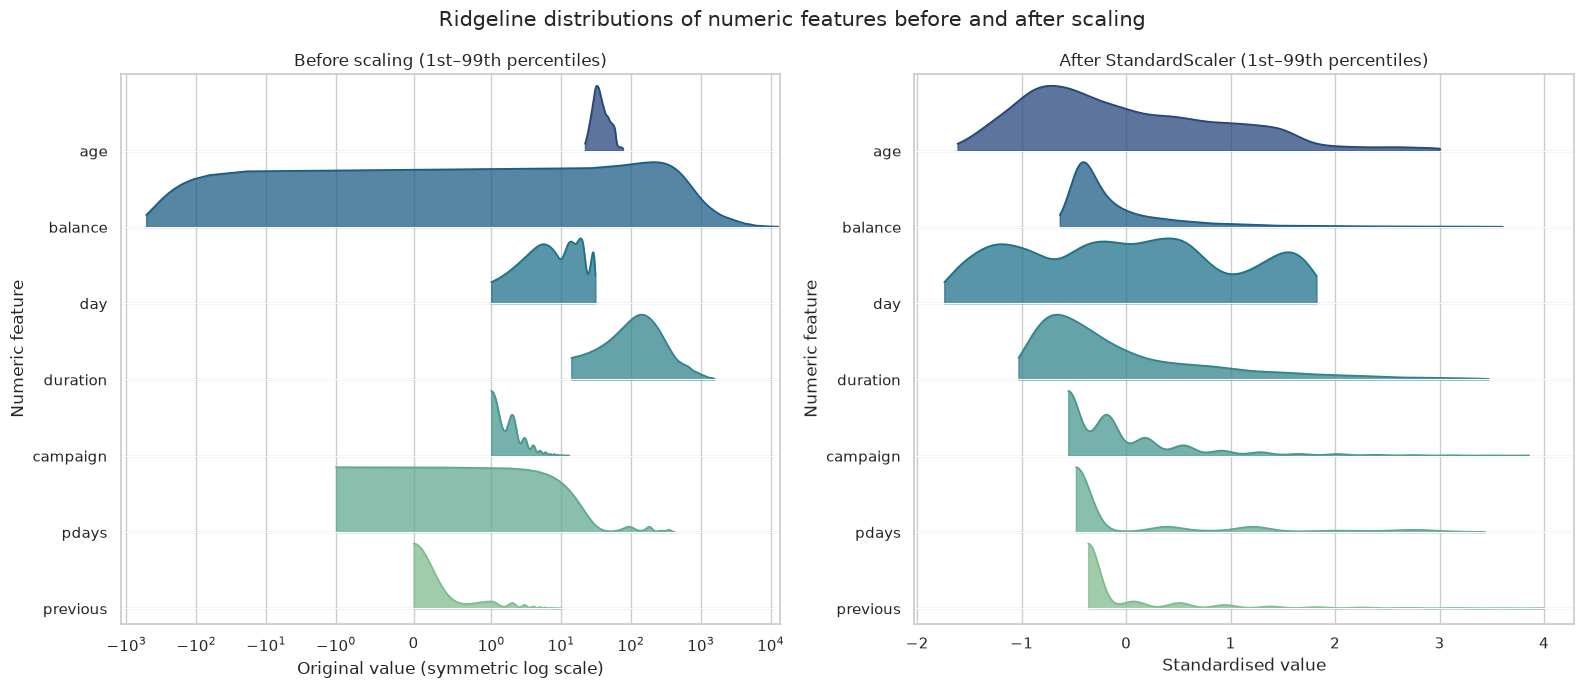

In [11]:
def draw_ridgeline(
    ax: plt.Axes, frame: pd.DataFrame, columns: list[str], title: str, *, use_symlog: bool = False
) -> None:
    colours = sns.color_palette("crest", n_colors=len(columns))
    display_columns = list(reversed(columns))
    for offset, (column, colour) in enumerate(zip(display_columns, colours)):
        values = frame[column].dropna().astype(float)
        lower, upper = values.quantile([0.01, 0.99])
        visible_values = values[values.between(lower, upper)]
        if visible_values.nunique() < 2:
            continue
        x_grid = np.linspace(visible_values.min(), visible_values.max(), 300)
        density = gaussian_kde(visible_values)(x_grid)
        density = density / density.max() * 0.85
        ax.fill_between(x_grid, offset, offset + density, color=colour, alpha=0.75)
        ax.plot(x_grid, offset + density, color=colour, linewidth=1.2)
        ax.axhline(offset, color="white", linewidth=0.8)
    ax.set_yticks(range(len(display_columns)), labels=display_columns)
    ax.set_ylim(-0.2, len(display_columns))
    ax.set_title(title)
    ax.set_ylabel("Numeric feature")
    if use_symlog:
        ax.set_xscale("symlog", linthresh=1)

# This scaler is descriptive only; the model scaler is fitted later using training data only.
eda_scaler = StandardScaler()
scaled_numeric_for_plot = pd.DataFrame(
    eda_scaler.fit_transform(data[NUMERIC_COLUMNS]),
    columns=NUMERIC_COLUMNS,
    index=data.index,
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
draw_ridgeline(axes[0], data, NUMERIC_COLUMNS, "Before scaling (1st–99th percentiles)", use_symlog=True)
draw_ridgeline(axes[1], scaled_numeric_for_plot, NUMERIC_COLUMNS, "After StandardScaler (1st–99th percentiles)")
axes[0].set_xlabel("Original value (symmetric log scale)")
axes[1].set_xlabel("Standardised value")
fig.suptitle("Ridgeline distributions of numeric features before and after scaling", fontsize=15)
plt.tight_layout()
plt.show()

## 5. Feature engineering and stratified data splitting

The split is 70% training, 15% validation and 15% testing. Both split stages use stratification and a fixed seed. This is especially important because the downloaded file is ordered by the target.

`pdays = -1` represents no previous contact. It is converted into two clearer features: a binary previous-contact indicator and a numeric days-since-contact field with missing values imputed from training data.

In [12]:
def engineer_features(frame: pd.DataFrame, use_duration: bool = True) -> pd.DataFrame:
    engineered = frame.drop(columns=[TARGET_COLUMN], errors="ignore").copy()
    engineered["previously_contacted"] = engineered["pdays"].ne(-1).astype(int)
    engineered["pdays_since_previous"] = engineered["pdays"].mask(engineered["pdays"].eq(-1))
    engineered = engineered.drop(columns=["pdays"])
    if not use_duration:
        engineered = engineered.drop(columns=["duration"])
    return engineered

X = engineer_features(data, use_duration=USE_DURATION)
y = data[TARGET_COLUMN].map({"no": 0, "yes": 1}).astype(int)

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y, shuffle=True
)
relative_validation_size = VALIDATION_SIZE / (1 - TEST_SIZE)
X_train, X_validation, y_train, y_validation = train_test_split(
    X_train_val,
    y_train_val,
    test_size=relative_validation_size,
    random_state=SEED,
    stratify=y_train_val,
    shuffle=True,
)

split_summary = pd.DataFrame({
    "records": [len(y_train), len(y_validation), len(y_test)],
    "fraction": [len(y_train) / len(y), len(y_validation) / len(y), len(y_test) / len(y)],
    "positive_rate": [y_train.mean(), y_validation.mean(), y_test.mean()],
}, index=["train", "validation", "test"])
display(split_summary)

,records,fraction,positive_rate
train,7812,0.700,0.474
validation,1675,0.150,0.474
test,1675,0.150,0.474


## 6. Model preprocessing

An MLP does not mathematically require manual scaling, but scaling is strongly recommended because gradient-based optimisation is more stable when numeric features have comparable magnitudes. The model's `StandardScaler` is fitted **only on the training set**. Categorical variables are one-hot encoded and unseen categories are ignored safely. The earlier descriptive plot uses the same scaling method but a separate display-only scaler; it is never used to transform model inputs.

In [13]:
model_numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
model_categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, model_numeric_features),
    ("categorical", categorical_pipeline, model_categorical_features),
])

X_train_processed = preprocessor.fit_transform(X_train)
X_validation_processed = preprocessor.transform(X_validation)
X_test_processed = preprocessor.transform(X_test)

print(f"Numeric features: {model_numeric_features}")
print(f"Categorical features: {model_categorical_features}")
print(f"Processed shapes: train={X_train_processed.shape}, validation={X_validation_processed.shape}, test={X_test_processed.shape}")

Numeric features: ['age', 'balance', 'day', 'duration', 'campaign', 'previous', 'previously_contacted', 'pdays_since_previous']
Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Processed shapes: train=(7812, 52), validation=(1675, 52), test=(1675, 52)


In [14]:
fitted_numeric_pipeline = preprocessor.named_transformers_["numeric"]
fitted_scaler = fitted_numeric_pipeline.named_steps["scaler"]
scaling_parameters = pd.DataFrame({
    "training_mean": fitted_scaler.mean_,
    "training_standard_deviation": fitted_scaler.scale_,
}, index=model_numeric_features)
display(scaling_parameters)

,training_mean,training_standard_deviation
age,41.118,11.878
balance,"1,483.215","3,090.793"
day,15.680,8.395
duration,372.140,348.208
campaign,2.509,2.784
previous,0.832,2.278
previously_contacted,0.254,0.435
pdays_since_previous,188.696,61.984


## 7. Train the MLP with validation-based early stopping

Architecture: input → 64 ReLU units → 32 ReLU units → binary probability. L2 regularisation is controlled by `alpha`. The notebook trains one epoch at a time, records training and validation loss/AUC, and restores the model from the epoch with the lowest validation loss.

In [15]:
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    batch_size=64,
    learning_rate_init=1e-3,
    max_iter=1,
    shuffle=True,
    random_state=SEED,
)

history = {"train_loss": [], "validation_loss": [], "train_auc": [], "validation_auc": []}
best_model = None
best_validation_loss = np.inf
best_epoch = 0
epochs_without_improvement = 0
classes = np.array([0, 1])

for epoch in range(1, MAX_EPOCHS + 1):
    if epoch == 1:
        mlp.partial_fit(X_train_processed, y_train, classes=classes)
    else:
        mlp.partial_fit(X_train_processed, y_train)

    train_probability = mlp.predict_proba(X_train_processed)[:, 1]
    validation_probability = mlp.predict_proba(X_validation_processed)[:, 1]
    train_loss = log_loss(y_train, train_probability, labels=classes)
    validation_loss = log_loss(y_validation, validation_probability, labels=classes)

    history["train_loss"].append(train_loss)
    history["validation_loss"].append(validation_loss)
    history["train_auc"].append(roc_auc_score(y_train, train_probability))
    history["validation_auc"].append(roc_auc_score(y_validation, validation_probability))

    if validation_loss < best_validation_loss - MIN_DELTA:
        best_validation_loss = validation_loss
        best_epoch = epoch
        best_model = copy.deepcopy(mlp)
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping at epoch {epoch}.")
        break

if best_model is None:
    raise RuntimeError("Training did not produce a valid model.")
mlp = best_model
history_frame = pd.DataFrame(history, index=np.arange(1, len(history["train_loss"]) + 1))
history_frame.index.name = "epoch"
print(f"Best epoch: {best_epoch}; best validation loss: {best_validation_loss:.4f}")
history_frame.tail()

Early stopping at epoch 24.
Best epoch: 12; best validation loss: 0.3438


,train_loss,validation_loss,train_auc,validation_auc
epoch,,,,
20,0.271,0.352,0.953,0.922
21,0.267,0.355,0.955,0.922
22,0.264,0.357,0.956,0.921
23,0.260,0.360,0.957,0.921
24,0.257,0.362,0.958,0.921


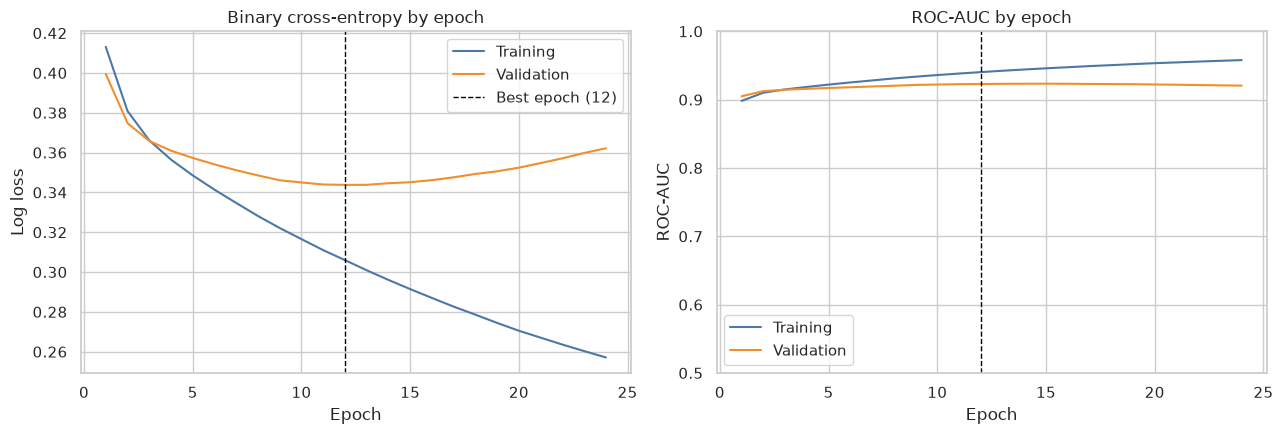

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(history_frame.index, history_frame["train_loss"], label="Training", color="#4C78A8")
axes[0].plot(history_frame.index, history_frame["validation_loss"], label="Validation", color="#F28E2B")
axes[0].axvline(best_epoch, color="black", linestyle="--", linewidth=1, label=f"Best epoch ({best_epoch})")
axes[0].set(title="Binary cross-entropy by epoch", xlabel="Epoch", ylabel="Log loss")
axes[0].legend()

axes[1].plot(history_frame.index, history_frame["train_auc"], label="Training", color="#4C78A8")
axes[1].plot(history_frame.index, history_frame["validation_auc"], label="Validation", color="#F28E2B")
axes[1].axvline(best_epoch, color="black", linestyle="--", linewidth=1)
axes[1].set(title="ROC-AUC by epoch", xlabel="Epoch", ylabel="ROC-AUC", ylim=(0.5, 1.0))
axes[1].legend()
plt.tight_layout()
plt.show()

## 8. Final evaluation

The classification threshold is fixed at 0.5. The test set is used only here, after preprocessing and model selection are complete. Accuracy is reported together with balanced accuracy, precision, recall, F1, ROC-AUC and log loss so that different types of classification error remain visible.

In [17]:
def metric_row(name: str, labels: pd.Series, probabilities: np.ndarray, threshold: float = 0.5) -> dict[str, float | str]:
    predictions = (probabilities >= threshold).astype(int)
    return {
        "split": name,
        "accuracy": accuracy_score(labels, predictions),
        "balanced_accuracy": balanced_accuracy_score(labels, predictions),
        "precision": precision_score(labels, predictions, zero_division=0),
        "recall": recall_score(labels, predictions, zero_division=0),
        "f1": f1_score(labels, predictions, zero_division=0),
        "roc_auc": roc_auc_score(labels, probabilities),
        "log_loss": log_loss(labels, probabilities, labels=[0, 1]),
    }

train_probability = mlp.predict_proba(X_train_processed)[:, 1]
validation_probability = mlp.predict_proba(X_validation_processed)[:, 1]
test_probability = mlp.predict_proba(X_test_processed)[:, 1]
test_prediction = (test_probability >= 0.5).astype(int)

metrics_table = pd.DataFrame([
    metric_row("train", y_train, train_probability),
    metric_row("validation", y_validation, validation_probability),
    metric_row("test", y_test, test_probability),
]).set_index("split")
display(metrics_table.style.format("{:.3f}"))

class_report = pd.DataFrame(
    classification_report(
        y_test, test_prediction, target_names=["no", "yes"], output_dict=True, zero_division=0
    )
).T
display(class_report.style.format("{:.3f}"))

,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,log_loss
split,,,,,,,
train,0.872,0.873,0.838,0.904,0.870,0.940,0.306
validation,0.856,0.857,0.830,0.877,0.852,0.923,0.344
test,0.849,0.851,0.813,0.884,0.847,0.916,0.358


,precision,recall,f1-score,support
no,0.887,0.817,0.851,881.000
yes,0.813,0.884,0.847,794.000
accuracy,0.849,0.849,0.849,0.849
macro avg,0.850,0.851,0.849,1675.000
weighted avg,0.852,0.849,0.849,1675.000


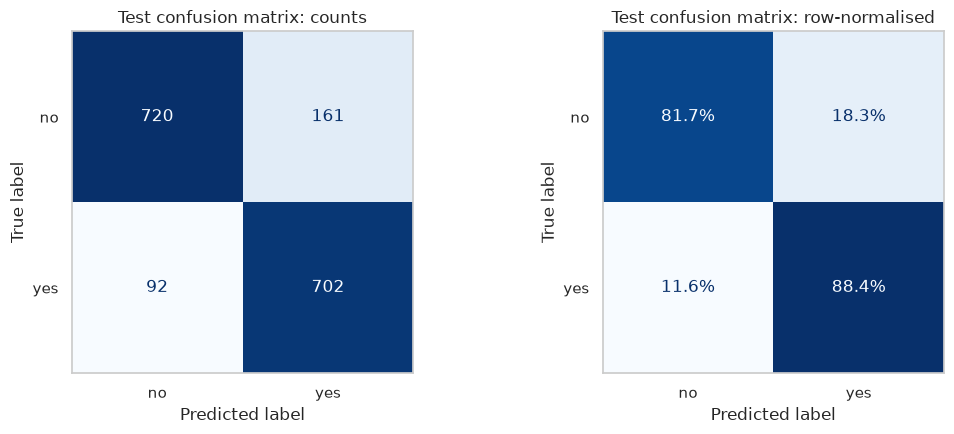

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
raw_matrix = confusion_matrix(y_test, test_prediction)
normalised_matrix = confusion_matrix(y_test, test_prediction, normalize="true")

ConfusionMatrixDisplay(raw_matrix, display_labels=["no", "yes"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False, values_format="d"
)
axes[0].grid(False)
axes[0].set_title("Test confusion matrix: counts")
ConfusionMatrixDisplay(normalised_matrix, display_labels=["no", "yes"]).plot(
    ax=axes[1], cmap="Blues", colorbar=False, values_format=".1%"
)
axes[1].set_title("Test confusion matrix: row-normalised")
axes[1].grid(False)
plt.tight_layout()
plt.show()

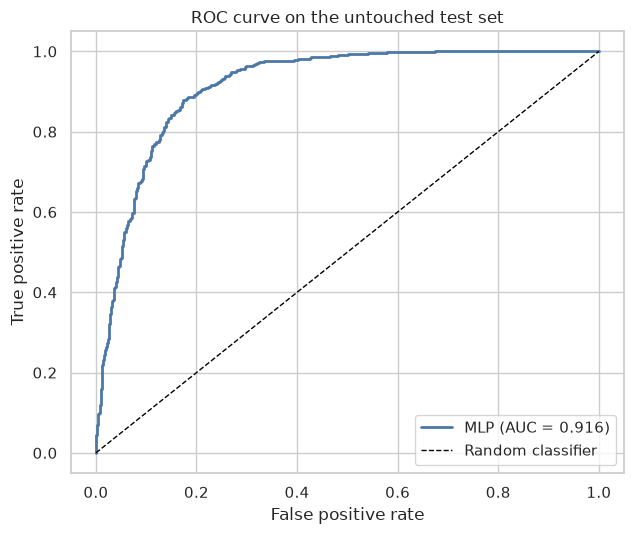

In [19]:
false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test, test_probability)
test_auc = roc_auc_score(y_test, test_probability)

plt.figure(figsize=(6.5, 5.5))
plt.plot(false_positive_rate, true_positive_rate, color="#4C78A8", linewidth=2, label=f"MLP (AUC = {test_auc:.3f})")
plt.plot([0, 1], [0, 1], color="black", linestyle="--", linewidth=1, label="Random classifier")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve on the untouched test set")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()